<a href="https://colab.research.google.com/github/Khushibung05/CNN/blob/main/Fashion_mnist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from tensorflow.keras.datasets import fashion_mnist
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [8]:
class_names = [
'T-shirt',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

Display 10 Random Images

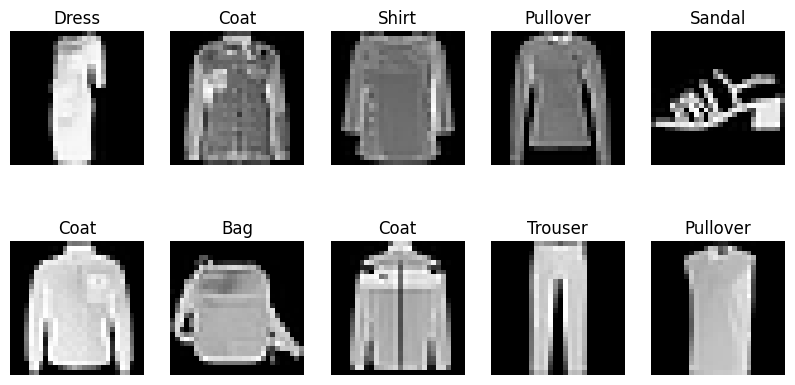

In [9]:
plt.figure(figsize=(10,5))

for i in range(10):

    index = np.random.randint(0,60000)

    img = X_train[index]
    label = y_train[index]

    plt.subplot(2,5,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(class_names[label])
    plt.axis('off')

plt.show()

Task 2 — Data Preprocessing

Normalize and Reshape

In [10]:
# normalize and reshape
X_train = X_train.reshape(-1,28,28,1).astype('float32')/255
X_test = X_test.reshape(-1,28,28,1).astype('float32')/255

In [11]:
# one-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

Task 3 — Visualize Class Distribution

Count Images Per Class

In [12]:
labels = np.argmax(y_train,axis=1)

unique, counts = np.unique(labels, return_counts=True)

print(dict(zip(unique,counts)))

{np.int64(0): np.int64(6000), np.int64(1): np.int64(6000), np.int64(2): np.int64(6000), np.int64(3): np.int64(6000), np.int64(4): np.int64(6000), np.int64(5): np.int64(6000), np.int64(6): np.int64(6000), np.int64(7): np.int64(6000), np.int64(8): np.int64(6000), np.int64(9): np.int64(6000)}


Plot class distribution

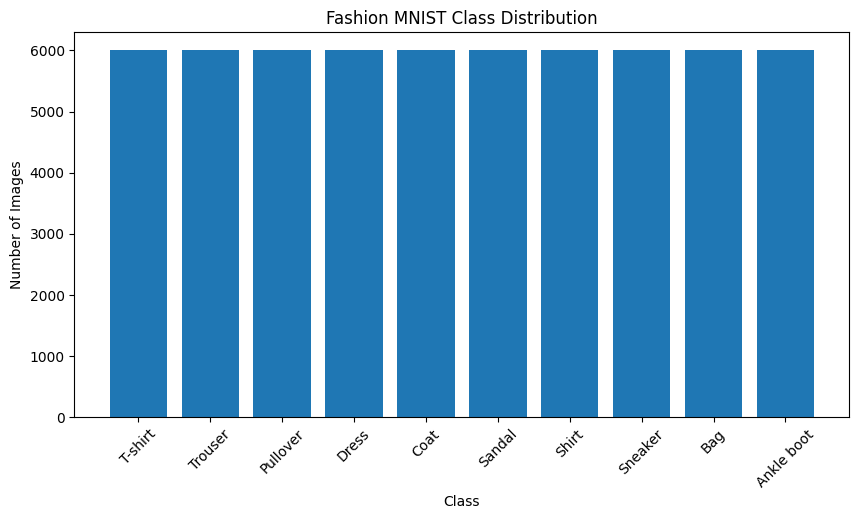

In [13]:
plt.figure(figsize=(10,5))

plt.bar(class_names,counts)

plt.title("Fashion MNIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

Result:

Fashion-MNIST dataset is perfectly balanced

Task 4 — Build First CNN Architecture

Students must implement a CNN with this architecture:

Input (28x28x1)

↓

Conv2D (32 filters, 3x3)

↓

ReLU

↓

MaxPooling (2x2)

↓

Conv2D (64 filters, 3x3)

↓

ReLU

↓

MaxPooling (2x2)

↓

Flatten

↓

Dense (128)

↓

Softmax (10)

Goal:

Understand basic CNN architecture.

In [15]:
model = Sequential([

# Convolution Layer 1
Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),

# Max Pooling Layer
MaxPooling2D(pool_size=(2,2)),

# Convolution Layer 2
Conv2D(64, kernel_size=(3,3), activation='relu'),

# Max Pooling Layer
MaxPooling2D(pool_size=(2,2)),

# Flatten the feature maps
Flatten(),

# Fully Connected Layer
Dense(128, activation='relu'),

# Output Layer (10 classes)
Dense(10, activation='softmax')

])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

| Layer               | Purpose                                           |
| ------------------- | ------------------------------------------------- |
| Input Layer         | Receives image of size **28×28×1**                |
| Conv2D (32 filters) | Detects simple patterns like edges and shapes     |
| ReLU                | Activation function that introduces non-linearity |
| MaxPooling (2×2)    | Reduces image size and keeps important features   |
| Conv2D (64 filters) | Detects more complex patterns                     |
| Flatten             | Converts 2D feature maps to 1D vector             |
| Dense (128)         | Learns high-level features                        |
| Softmax (10)        | Outputs probability for **10 clothing classes**   |


Task 5 — Model Compilation

After building the CNN architecture, the model must be compiled.
Compilation defines:

Optimizer → how the model updates weights

Loss function → how error is measured

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model training:

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.9027 - loss: 0.2645 - val_accuracy: 0.9005 - val_loss: 0.2756
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - accuracy: 0.9148 - loss: 0.2339 - val_accuracy: 0.9099 - val_loss: 0.2554
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.9246 - loss: 0.2065 - val_accuracy: 0.8987 - val_loss: 0.2844
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.9298 - loss: 0.1888 - val_accuracy: 0.9141 - val_loss: 0.2435
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9352 - loss: 0.1753 - val_accuracy: 0.9094 - val_loss: 0.2618
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9424 - loss: 0.1554 - val_accuracy: 0.9130 - val_loss: 0.2495
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - accuracy: 0.9490 - loss: 0.1356 - val_accuracy: 0.9085 - val_loss: 0.2592
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.9532 - loss: 0.1253 - 

model evaluation:

In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9041 - loss: 0.3271
Test accuracy: 0.9061999917030334
Test loss: 0.3236639201641083


plot training vs model accuracy

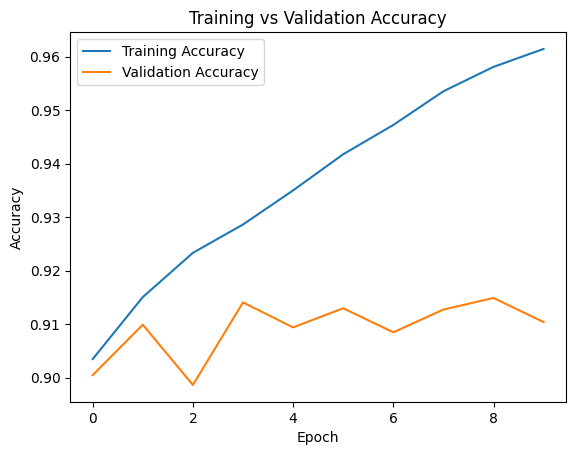

In [23]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

plot training vs loss

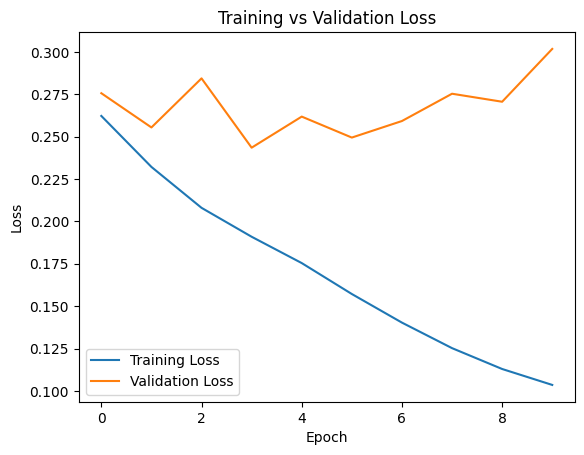

In [24]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Observe how accuracy improves during training.

Observe how error decreases during training.

make predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


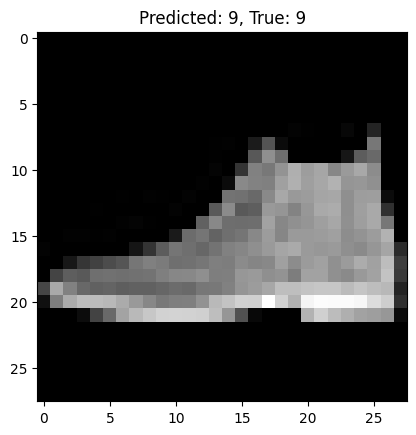

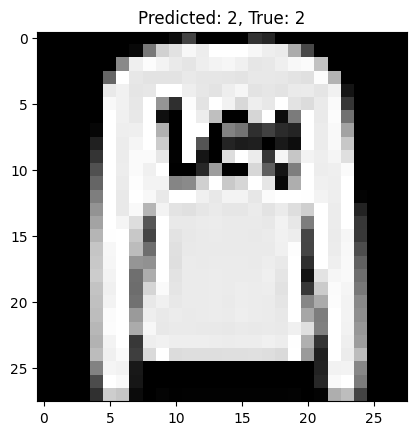

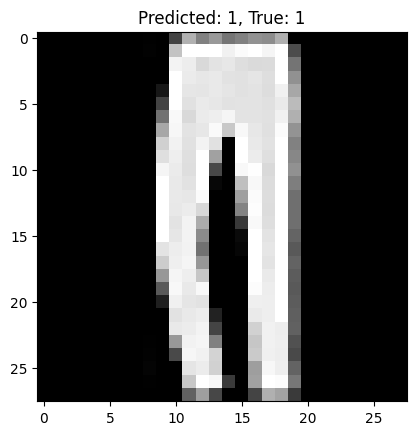

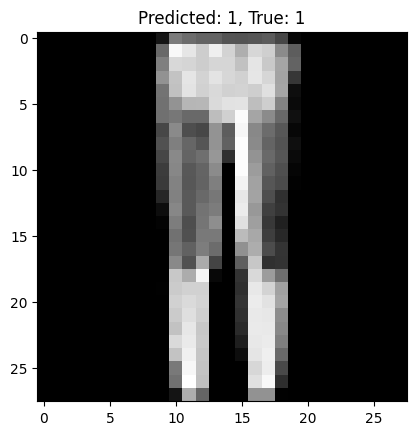

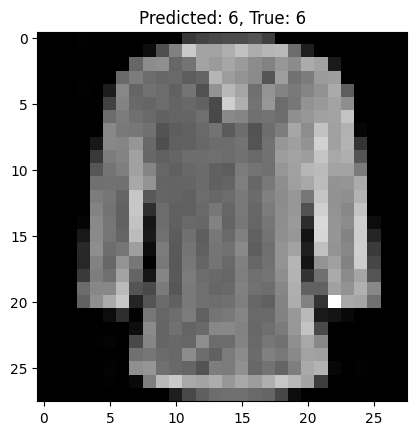

In [22]:
prediction = model.predict(X_test[:5])

predicted_classes = np.argmax(prediction, axis=1)
true_classes = np.argmax(y_test[:5], axis=1)

for i in range(5):

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(f"Predicted: {predicted_classes[i]}, True: {true_classes[i]}")

    plt.show()

Task 8 — Confusion Matrix Analysis



In [27]:
y_pred = model.predict(X_test)

predicted_classes = np.argmax(y_pred, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


[[832   0  22  28   1   2 103   0  11   1]
 [  0 981   2   9   2   0   2   0   4   0]
 [ 16   0 914  11  23   0  35   0   1   0]
 [  5   3  12 934  13   0  24   0   9   0]
 [  1   0  87  46 796   0  65   0   5   0]
 [  0   0   0   0   0 956   0  36   1   7]
 [ 89   1  92  34  46   0 721   1  16   0]
 [  0   0   0   0   0   1   0 982   0  17]
 [  1   0   4   0   1   1   2   3 987   1]
 [  1   0   0   0   0   4   0  36   0 959]]


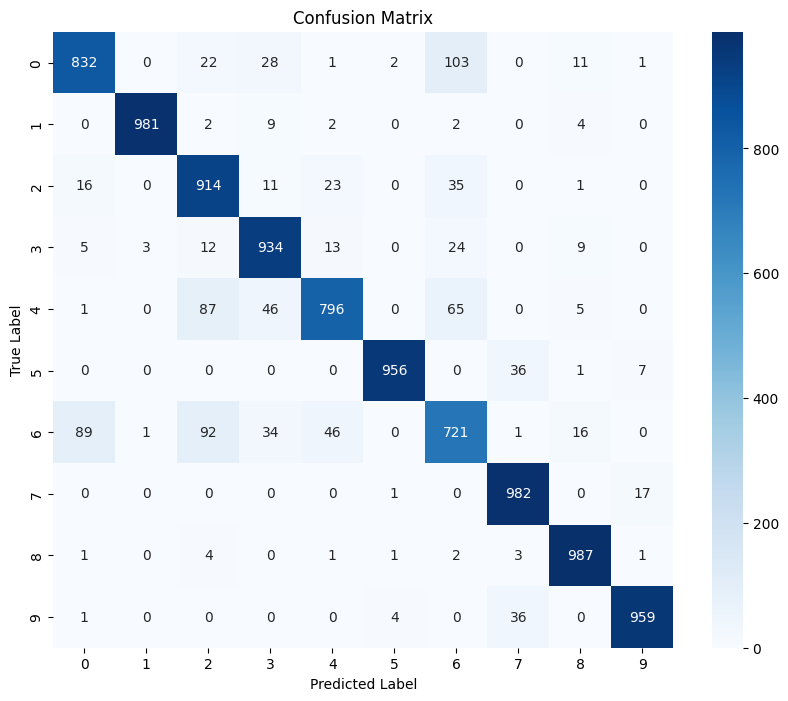

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

Task 9 — Improve the CNN Architecture
Students must modify the architecture by:

Adding Dropout layer
Increasing filters
Adding another convolution layer

Example:
Conv → Conv → Pool → Conv → Pool

Then compare:
Model 1 accuracy vs Model 2 accuracy

Goal:
Understand model improvement strategies

In [29]:
from keras.layers import Dropout

model2 = Sequential([

Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
Conv2D(32, kernel_size=(3,3), activation='relu'),

MaxPooling2D(pool_size=(2,2)),

Conv2D(64, kernel_size=(3,3), activation='relu'),

MaxPooling2D(pool_size=(2,2)),

Flatten(),

Dense(128, activation='relu'),

Dropout(0.5),

Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model2.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [32]:
history2 = model2.fit(
X_train,
y_train,
epochs=10,
batch_size=64,
validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 118ms/step - accuracy: 0.6888 - loss: 0.8526 - val_accuracy: 0.8627 - val_loss: 0.3737
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.8524 - loss: 0.4144 - val_accuracy: 0.8846 - val_loss: 0.3094
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 108ms/step - accuracy: 0.8777 - loss: 0.3351 - val_accuracy: 0.8946 - val_loss: 0.2865
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 86s 114ms/step - accuracy: 0.8924 - loss: 0.2956 - val_accuracy: 0.9032 - val_loss: 0.2702
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.9040 - loss: 0.2688 - val_accuracy: 0.9072 - val_loss: 0.2512
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 105ms/step - accuracy: 0.9100 - loss: 0.2501 - val_accuracy: 0.9110 - val_loss: 0.2415
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.9181 - loss: 0.2341 - val_accuracy: 0.9120 - val_loss: 0.2362
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 105ms/step - accuracy: 0.9214 - loss: 0

In [33]:
test_loss2, test_acc2 = model2.evaluate(X_test, y_test)

print("Improved Model Test Accuracy:", test_acc2)
print("Improved Model Test Loss:", test_loss2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9127 - loss: 0.2520
Improved Model Test Accuracy: 0.9111999869346619
Improved Model Test Loss: 0.24866364896297455


Model 2 performs better because:

More convolution layers extract better features

More filters detect complex patterns

Dropout prevents overfitting

What Dropout Does

Dropout randomly turns off some neurons during training.

Example:

Dropout(0.5)

Means:

50% neurons are ignored during each training step.

This helps the model generalize better.|


In [34]:
misclassified = np.where(predicted_classes != true_classes)[0]

print("Total Misclassified Images:", len(misclassified))

Total Misclassified Images: 938


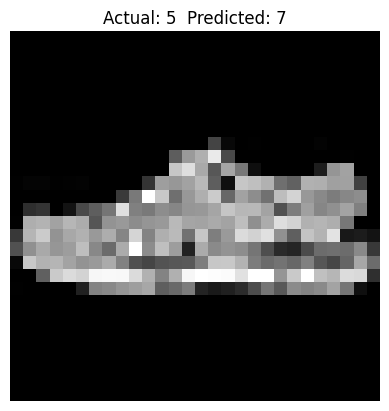

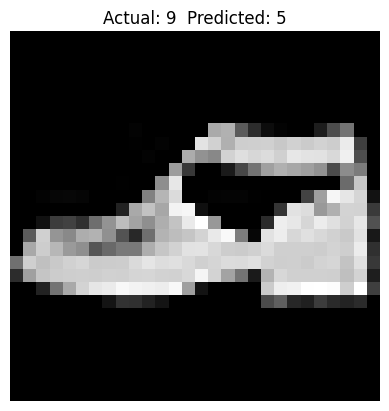

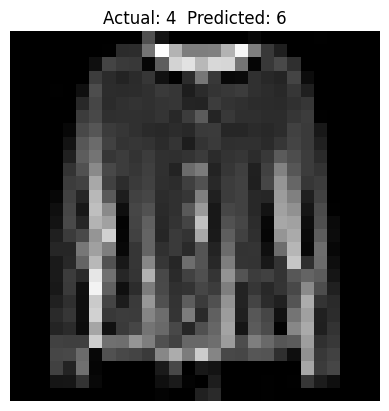

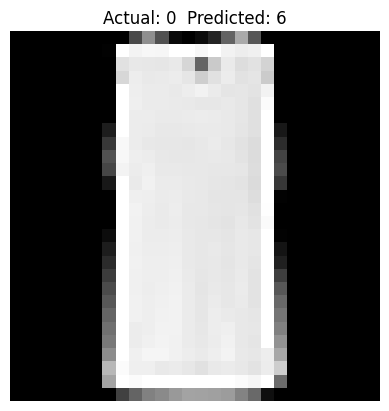

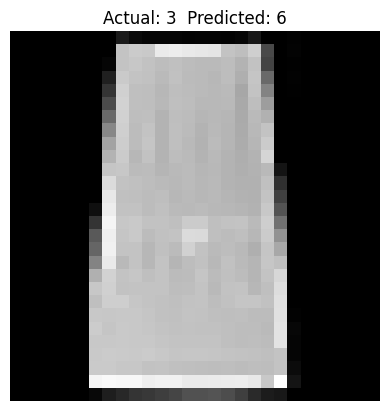

In [35]:
for i in misclassified[:5]:

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(f"Actual: {true_classes[i]}  Predicted: {predicted_classes[i]}")

    plt.axis('off')

    plt.show()

Task 11 — Feature Map Visualization

Goal: See what the CNN learns internally.

In [37]:
#extract intermediate layer
from tensorflow.keras.models import Model

layer_outputs = [layer.output for layer in model.layers[:4]]

feature_model = Model(inputs=model.layers[0].input, outputs=layer_outputs)

In [38]:
#select 1 image
img = X_test[0].reshape(1,28,28,1)

feature_maps = feature_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


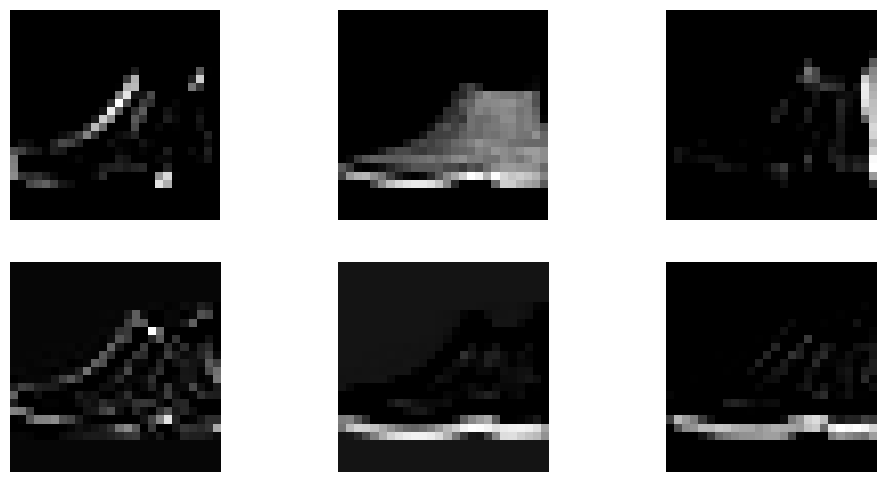

In [39]:
#visualize feature maps
plt.figure(figsize=(12,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(feature_maps[0][0,:,:,i], cmap='gray')

    plt.axis('off')

plt.show()

Task 12 — Build Simple Prediction Interface

Goal: Simulate real-world prediction.

In [40]:
class_names = [
'T-shirt',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

In [41]:
#Step 2 — Select Random Test Image
index = np.random.randint(0, len(X_test))

image = X_test[index]
true_label = np.argmax(y_test[index])

In [42]:
#Step 3 — Predict Image Class
prediction = model.predict(image.reshape(1,28,28,1))

predicted_class = np.argmax(prediction)

probability = np.max(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


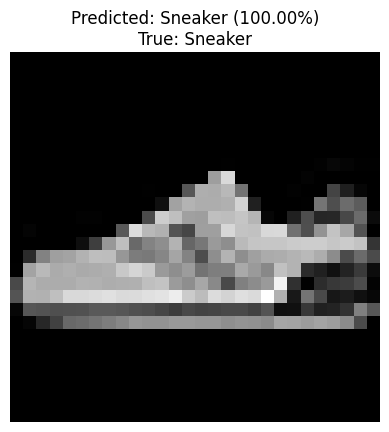

In [43]:
#Step 4 — Display Prediction
plt.imshow(image.reshape(28,28), cmap='gray')

plt.title(f"Predicted: {class_names[predicted_class]} ({probability*100:.2f}%)\nTrue: {class_names[true_label]}")

plt.axis('off')

plt.show()